# 04b — Walk-Forward Trading Strategy and Performance Evaluation — NQ

## Purpose

Notebooks 02 and 03 were **explanatory**: they measured how ES responds to macro surprises and whether the pre-event state changes that response, using the full sample.

Notebook 04 asks the **practical** question:

> **Could a trader have made money from these relationships in real time, after transaction costs, using only information available at each point in time?**

It then compares three kinds of model:

| Model | Idea |
|---|---|
| **Surprise only** | Trade the direction implied by the surprise (Notebook 02) |
| **Surprise + State** | Let the pre-event state change the surprise beta (Notebook 03) |
| **Naive sign rule** | No estimation at all: trade the economically expected sign (sanity benchmark) |

> **04b — E-mini Nasdaq-100 (NQ).** This notebook is Notebook 04 (ES) run on **NQ**, with identical code and parameters.
> - Prices: Jack Duncan's cleaned 1-minute file `futures_1min_clean_v3_NQ.parquet` (team repo), roll-adjusted the same way. The variables `es` / `es_adj` hold **NQ** bars (names kept from the ES notebook).
> - Costs: 2 ticks + $4.50 per round trip on the NQ contract (tick 0.25, $20 per point).
> - Outputs are saved as `nb04b_NQ_*` (results, figures), so nothing from the ES notebook is overwritten.
> - **Text cells are copied from the ES notebook.** Where they quote ES numbers or say "ES", they describe the ES study; the NQ results are in the outputs.
> - Run order: 03b → 04b → 05b → 06b for the same market (each reads the previous one's files).

## Notebook Workflow

| Step | What happens | Output |
|---|---|---|
| 1 | Setup and pre-registered parameters | — |
| 2 | Load the NB03 event-state dataset | event table |
| 3 | Build trade returns from 1-minute ES (entry latency × holding period) | `tr_L{lag}_H{h}` |
| 4 | Transaction cost model | cost in bps per event |
| 5 | Define strategies | 5 strategies |
| 6 | Run the walk-forward backtest | trade log |
| 7 | Walk-forward coefficient paths: what the model believed over time | figure |
| 8 | Performance evaluation: Sharpe, return, drawdown, hit rate, costs | `nb04_performance_*.csv` |
| 9 | Cumulative P&L and drawdowns | figures |
| 10 | P&L by year and by volatility state | tables |
| 11 | Statistical comparison: does adding state beat surprise only? | bootstrap tests |
| 12 | Robustness: costs, latency and holding period, window, threshold | sensitivity tables |
| 13 | What did the adaptive model choose? | state usage |
| 14 | Final comparison, saved outputs and conclusion | `nb04_final_comparison.csv` |

## Methodology

**1. Timing (no look-ahead).** A release at $T$ is traded at the close of the first post-release bar (label $T$, about 1 minute after the release). It exits at the close of bar $T+h-1$. The base case is $h = 30$, the pre-registered NB03 target `drift_30m`. The instant jump inside the first minute is **not** captured.

**2. Walk-forward estimation.** For every event, the model is re-estimated using **only earlier releases of the same family**, on an expanding window. Trading starts once 36 past releases exist (about 3 years), so the evaluation period is **2019–2026** and 2016–2018 is used only for training.

**3. Trade rule.** The model gives an expected surprise-driven return $\hat{r}$ in bps. The strategy goes long or short one unit of notional in the direction of $\hat{r}$, **only if $|\hat{r}|$ exceeds the round-trip transaction cost**. There is no intercept term: the strategy trades the *surprise*, not an average post-release drift.

$$\text{Surprise only:}\quad \hat{r} = \hat b_t\,x \qquad\qquad \text{Surprise + State:}\quad \hat{r} = (\hat b_t + \hat d_t\,s)\,x,\quad s=\text{pct}-0.5$$

**4. Transaction costs.** Each round trip pays slippage plus commission. The base case is 2 ticks (1 per side) plus $4.50 per contract, which is about 1.2 bps at ES 5,000. Sensitivity runs from 0 to 8 ticks.

**5. Selection-bias control.** NB03 chose `rv_20d` using the **full sample**, which is information a trader in 2019 did not have. Two strategies address this:
- **State filter:** a simple, transparent rule that only skips CPI trades in low-volatility states.
- **Adaptive state:** at each event, it picks whichever of the six states has the strongest interaction *in the training data only*, and uses it only if $|t| \ge 2$. **This is the honest out-of-sample test of state conditioning.**

**6. Metrics.** Monthly returns on one unit of notional, with months without trades counted as 0, give the annualised return, volatility and Sharpe ratio. Also reported: maximum drawdown, hit rate, average P&L per trade, profit factor and total costs. Strategies are compared with a paired block bootstrap.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MARKET = "NQ"                      # this notebook's market
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
MARKET_FILE = TEAM_DATA / f"futures_1min_clean_v3_{MARKET}.parquet"   # Jack's cleaned 1-minute file
TICK, MULT = {f"{MARKET}": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0)}[MARKET]   # tick, $ per point
_BARS = {}
def load_market_minute():
    """1-minute bars of MARKET as [close, instrument_id] (loaded once, then cached).
    The variables `es` / `es_adj` below hold THIS market's bars (names kept from the ES notebook)."""
    if "bars" not in _BARS:
        import src.multi_asset as _ma
        _BARS["bars"] = _ma.load_bars(MARKET_FILE, "team_v3")
    return _BARS["bars"]

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

STATE_FILE = PROCESSED_DIR / f"event_state_features_2016_2026_{MARKET}.parquet"   # from NB03

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
importlib.reload(sc); importlib.reload(wf)

print("Project root:", PROJECT_ROOT)
print("NB03 state file exists:", STATE_FILE.exists())
print(f"{MARKET} raw file exists:", MARKET_FILE.exists())
wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT   # this market's contract


Project root: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises
NB03 state file exists: True
NQ raw file exists: True


In [2]:
# ---- market switch: costs, titles --------------------------------------------
if "wf" in globals():                       # walk-forward costs use this market's contract
    wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT
import re as _re, matplotlib.axes as _mx, matplotlib.figure as _mf
if not getattr(_mx.Axes.set_title, "_mkt", False):
    _T0_, _S0_ = _mx.Axes.set_title, _mf.Figure.suptitle
    def _set_title(self, label, *a, **k):
        return _T0_(self, _re.sub(r"\bES\b", MARKET, str(label)), *a, **k)
    def _suptitle(self, t, *a, **k):
        return _S0_(self, _re.sub(r"\bES\b", MARKET, str(t)), *a, **k)
    _set_title._mkt = True
    _mx.Axes.set_title, _mf.Figure.suptitle = _set_title, _suptitle
print(f"MARKET = {MARKET} | file: {MARKET_FILE.name} (exists: {MARKET_FILE.exists()}) | tick {TICK:g}, ${MULT:g} per point"
      f" | cost 2 ticks + $4.50 = {2 * TICK + 4.5 / MULT:.4f} points per round trip")

MARKET = NQ | file: futures_1min_clean_v3_NQ.parquet (exists: True) | tick 0.25, $20 per point | cost 2 ticks + $4.50 = 0.7250 points per round trip


### 1.1 Pre-registered parameters
These are fixed before any backtest is run. All sensitivity analyses are reported in Section 12, not used to pick the headline result.

In [3]:
FAMILIES = ["CPI", "PCE", "NFP"]
UNIVERSES = {                       # which releases each portfolio trades
    "CPI": ["CPI"],
    "CPI+PCE": ["CPI", "PCE"],
    "ALL": ["CPI", "PCE", "NFP"],
}

ENTRY_LAG = 0          # minutes after the first post-release bar
HOLD = 30              # exit at close of bar T+HOLD-1
TARGET = wf.trade_col(ENTRY_LAG, HOLD)

SLIPPAGE_TICKS_RT = 2.0     # round-trip ticks (1 per side)
COMMISSION_RT_USD = 4.5     # per contract, round trip
MIN_TRAIN = 36              # past releases of the same family before trading
THRESHOLD_MULT = 1.0        # trade if |expected return| > 1 x cost
STATE = "rv_20d"            # selected in NB03

EVAL_START = "2019-01-01"
EVAL_END = "2026-06-30"
N_BOOT = 5000

print("Target:", TARGET, "| eval:", EVAL_START, "to", EVAL_END)

Target: tr_L0_H30 | eval: 2019-01-01 to 2026-06-30


## 2. Load the NB03 Event-State Dataset

In [4]:
ev = pd.read_parquet(STATE_FILE)
ev["timestamp_utc"] = pd.to_datetime(ev["timestamp_utc"], utc=True)
ev = ev.sort_values("timestamp_utc").reset_index(drop=True)

print("Events:", len(ev), "| unique timestamps:", ev["timestamp_utc"].nunique())
print("Range:", ev["timestamp_utc"].min(), "to", ev["timestamp_utc"].max())
display(ev["event_type"].value_counts().rename("n_events").to_frame())

needed = ["x", "pre_close", "drift_30m_bps"] + [f"{s}_pct" for s in wf.PRIMARY_STATES]
missing = [c for c in needed if c not in ev.columns]
assert not missing, f"Missing columns from NB03 output: {missing}"
assert ev["timestamp_utc"].is_unique
display(ev[["timestamp_utc", "event_type", "x", "pre_close", "drift_30m_bps", "rv_20d_pct"]].head())

Events: 354 | unique timestamps: 354
Range: 2016-01-08 13:30:00+00:00 to 2026-06-25 12:30:00+00:00


,n_events
event_type,
NFP,121
PCE,118
CPI,115


,timestamp_utc,event_type,x,pre_close,drift_30m_bps,rv_20d_pct
0,2016-01-08 13:30:00+00:00,NFP,1.614,"4,335.500",-31.072,0.881
1,2016-01-20 13:30:00+00:00,CPI,0.803,"4,067.000",24.558,0.899
2,2016-02-01 13:30:00+00:00,PCE,1.321,"4,237.250",8.844,0.911
3,2016-02-05 13:30:00+00:00,NFP,-0.566,"4,156.000",-17.516,0.899
4,2016-02-19 13:30:00+00:00,CPI,-1.165,"4,143.500",-15.728,0.864


## 3. Trade Returns from 1-Minute ES Data

The trade return for entry latency $L$ and exit bar $h$ is

$$TR_{L,h} = \ln\left(\frac{P_{T+h-1}}{P_{T+L}}\right)\times 10^4 \ \text{bps}$$

using the roll-adjusted price from NB03. $L = 0$ is the base case. $L = 1, 2, 5$ test what happens if the trader reacts more slowly.

In [5]:
es = load_market_minute()
es_adj, _ = sc.build_adjusted_log_price(es)
print(f"{MARKET} bars loaded:", len(es_adj))

ENTRY_LAGS = [0, 1, 2, 5]
HOLDS = [5, 15, 30, 60]
ev = wf.compute_trade_returns(ev, es_adj, ENTRY_LAGS, HOLDS)
TR_COLS = [c for c in ev.columns if c.startswith("tr_L")]
print("Trade-return columns:", TR_COLS)

# Validation: lag-0 trade returns must equal NB03 drift returns
for h in HOLDS:
    gap = (ev[wf.trade_col(0, h)] - ev[f"drift_{h}m_bps"]).abs().max()
    print(f"max |tr_L0_H{h} - drift_{h}m| = {gap:.2e} bps")
    assert gap < 1e-6
print("Missing trade returns:", int(ev[TR_COLS].isna().sum().sum()))

NQ bars loaded: 5255764
Trade-return columns: ['tr_L0_H5', 'tr_L0_H15', 'tr_L0_H30', 'tr_L0_H60', 'tr_L1_H5', 'tr_L1_H15', 'tr_L1_H30', 'tr_L1_H60', 'tr_L2_H5', 'tr_L2_H15', 'tr_L2_H30', 'tr_L2_H60', 'tr_L5_H15', 'tr_L5_H30', 'tr_L5_H60']
max |tr_L0_H5 - drift_5m| = 0.00e+00 bps
max |tr_L0_H15 - drift_15m| = 0.00e+00 bps
max |tr_L0_H30 - drift_30m| = 0.00e+00 bps
max |tr_L0_H60 - drift_60m| = 0.00e+00 bps
Missing trade returns: 0


## 4. Transaction Cost Model

In [6]:
ev["cost_bps"] = wf.round_trip_cost_bps(ev["pre_close"], SLIPPAGE_TICKS_RT, COMMISSION_RT_USD)
print(f"Base case: {SLIPPAGE_TICKS_RT} ticks round trip + ${COMMISSION_RT_USD} commission")
display(ev.groupby(ev["timestamp_utc"].dt.year)["cost_bps"].mean().rename("avg round-trip cost (bps)").to_frame().T)

print("\nCost vs. typical move (base case):")
display(pd.DataFrame({
    "mean |30m drift| (bps)": ev.groupby("event_type")[TARGET].apply(lambda v: v.abs().mean()),
    "avg cost (bps)": ev.groupby("event_type")["cost_bps"].mean(),
}).round(2))

Base case: 2.0 ticks round trip + $4.5 commission


timestamp_utc,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
avg round-trip cost (bps),1.598,1.263,1.036,0.958,0.716,0.506,0.570,0.515,0.381,0.331,0.272



Cost vs. typical move (base case):


,mean |30m drift| (bps),avg cost (bps)
event_type,,
CPI,26.330,0.720
NFP,23.950,0.780
PCE,15.390,0.760


Costs are small relative to typical post-release moves, since ES is one of the most liquid futures in the world. The real question is whether the **predictable** part of the move exceeds the cost.

## 5. Strategy Definitions

In [7]:
SPECS = [
    wf.StrategySpec("Naive sign", "naive", min_train=MIN_TRAIN),
    wf.StrategySpec("Surprise only", "surprise", min_train=MIN_TRAIN, threshold_mult=THRESHOLD_MULT),
    wf.StrategySpec("Surprise + State", "state", state=STATE, min_train=MIN_TRAIN, threshold_mult=THRESHOLD_MULT),
    wf.StrategySpec("Surprise + State filter", "state_filter", state=STATE, min_train=MIN_TRAIN, threshold_mult=THRESHOLD_MULT),
    wf.StrategySpec("Surprise + Adaptive state", "adaptive", min_train=MIN_TRAIN, threshold_mult=THRESHOLD_MULT, t_min=2.0),
]
STRATS = [s.name for s in SPECS]
BASE, STATE_MODEL = "Surprise only", "Surprise + State"

display(pd.DataFrame([{
    "strategy": s.name, "model": s.model,
    "state": s.state if s.model in ("state", "state_filter") else ("chosen in training" if s.model == "adaptive" else "-"),
    "fitted walk-forward": s.model != "naive",
    "uses NB03 full-sample choice": s.model in ("state", "state_filter"),
} for s in SPECS]).set_index("strategy"))

,model,state,fitted walk-forward,uses NB03 full-sample choice
strategy,,,,
Naive sign,naive,-,False,False
Surprise only,surprise,-,True,False
Surprise + State,state,rv_20d,True,True
Surprise + State filter,state_filter,rv_20d,True,True
Surprise + Adaptive state,adaptive,chosen in training,True,False


## 6. Run the Walk-Forward Backtest

In [8]:
def run_all(specs, target=TARGET, ticks=SLIPPAGE_TICKS_RT, families=FAMILIES):
    return {s.name: wf.run_walk_forward(ev, s, target, families, ticks, COMMISSION_RT_USD) for s in specs}

trades = run_all(SPECS)

def universe(tr, fams):
    return tr[tr["event_type"].isin(fams)]

log = pd.concat(trades.values(), ignore_index=True)
log.to_csv(RESULTS_DIR / f"nb04b_{MARKET}_trade_log.csv", index=False)

first_trade = log[log["eligible"]].groupby("event_type")["timestamp_utc"].min()
print("First tradeable release per family (after", MIN_TRAIN, "training events):")
display(first_trade.to_frame("first_eligible"))

display(log[log["eligible"]].groupby(["strategy", "event_type"])["position"]
        .apply(lambda p: (p != 0).mean()).unstack().round(2)
        .rename(columns=lambda c: f"trade rate {c}"))

First tradeable release per family (after 36 training events):


,first_eligible
event_type,
CPI,2019-09-12 12:30:00+00:00
NFP,2019-01-04 13:30:00+00:00
PCE,2019-03-29 12:30:00+00:00


event_type,trade rate CPI,trade rate NFP,trade rate PCE
strategy,,,
Naive sign,1.000,1.000,1.000
Surprise + Adaptive state,0.810,0.230,0.730
Surprise + State,0.810,0.270,0.850
Surprise + State filter,0.460,0.130,0.460
Surprise only,0.780,0.190,0.730


## 7. Walk-Forward Coefficient Paths (CPI)

This shows what the model **believed at each point in time**: the surprise beta $\hat b_t$ from the surprise-only model, and the state interaction $\hat d_t$ from the surprise + state model. Both are estimated only from data before each release.

If $\hat d_t$ only becomes large after 2021, the state effect was **not knowable** early in the sample.

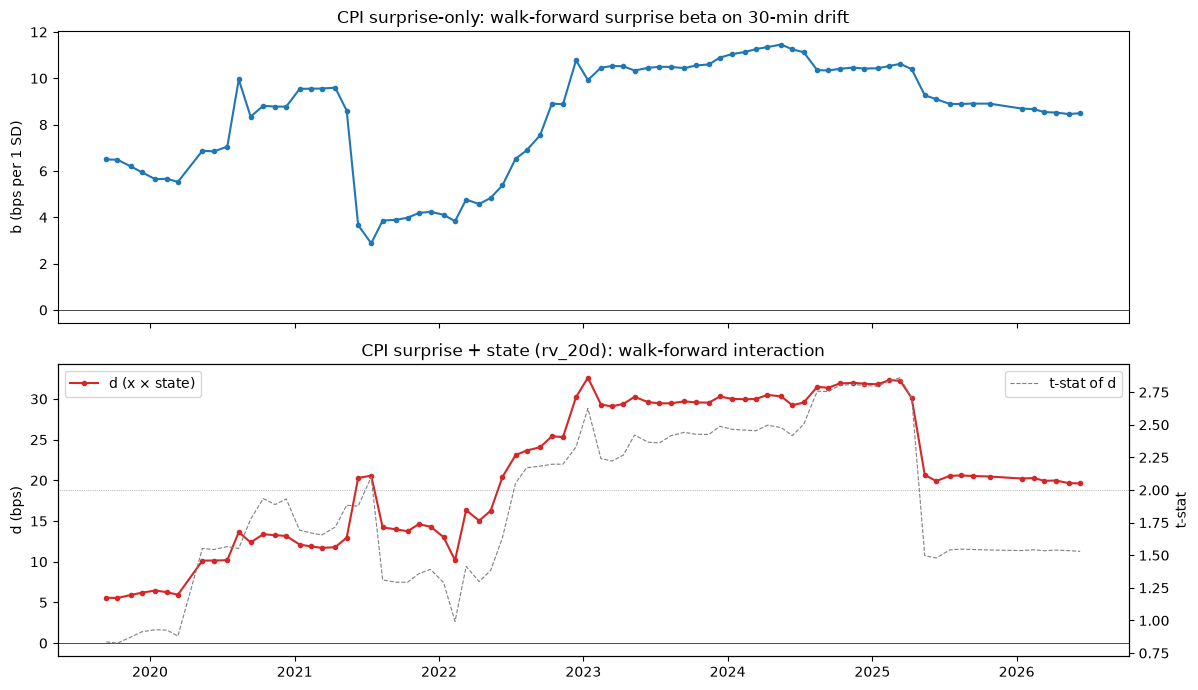

Coefficients at the last CPI release of each year:


,b,d,t_d,b_surprise_only
year,,,,
2019,6.530,6.200,0.910,5.940
2020,9.600,13.170,1.930,8.780
2021,7.720,14.310,1.390,4.240
2022,15.260,30.230,2.330,10.780
2023,15.610,30.300,2.490,10.900
2024,15.370,31.870,2.800,10.420
2025,11.870,20.470,1.540,8.910
2026,11.330,19.620,1.530,8.490


In [9]:
cpi_s = universe(trades[BASE], ["CPI"]).query("eligible")
cpi_ss = universe(trades[STATE_MODEL], ["CPI"]).query("eligible")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(cpi_s["timestamp_utc"], cpi_s["b"], marker="o", ms=3)
axes[0].axhline(0, c="k", lw=0.5)
axes[0].set_ylabel("b (bps per 1 SD)"); axes[0].set_title("CPI surprise-only: walk-forward surprise beta on 30-min drift")
axes[1].plot(cpi_ss["timestamp_utc"], cpi_ss["d"], marker="o", ms=3, c="C3", label="d (x × state)")
ax2 = axes[1].twinx()
ax2.plot(cpi_ss["timestamp_utc"], cpi_ss["t_d"], c="gray", lw=0.8, ls="--", label="t-stat of d")
ax2.axhline(2, c="gray", lw=0.5, ls=":"); ax2.set_ylabel("t-stat")
axes[1].axhline(0, c="k", lw=0.5); axes[1].set_ylabel("d (bps)")
axes[1].set_title(f"CPI surprise + state ({STATE}): walk-forward interaction")
axes[1].legend(loc="upper left"); ax2.legend(loc="upper right")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb04b_{MARKET}_cpi_coefficient_paths.png", dpi=150); plt.show()

yearly_coef = (cpi_ss.assign(year=cpi_ss["timestamp_utc"].dt.year)
               .groupby("year")[["b", "d", "t_d"]].last())
yearly_coef["b_surprise_only"] = cpi_s.assign(year=cpi_s["timestamp_utc"].dt.year).groupby("year")["b"].last()
print("Coefficients at the last CPI release of each year:")
display(yearly_coef.round(2))

## 8. Performance Evaluation

All metrics are on the common evaluation window. Returns are per unit of notional, so **1 bp = 0.01% of the contract value**. Annualised figures use monthly returns, with months without trades set to 0.

In [10]:
KEY_METRICS = ["trades", "trade_rate", "hit_rate", "avg_gross_bps", "avg_cost_bps", "avg_net_bps",
               "total_net_pct", "ann_return_pct", "ann_vol_pct", "sharpe_gross", "sharpe_net",
               "max_dd_pct", "t_stat_trade", "profit_factor"]

perf = {}
for uname, fams in UNIVERSES.items():
    perf[uname] = wf.perf_table({k: universe(v, fams) for k, v in trades.items()}, EVAL_START, EVAL_END)
    perf[uname].to_csv(RESULTS_DIR / f"nb04b_{MARKET}_performance_{uname.replace('+', '_')}.csv")
    print(f"\n=== Universe: {uname}  ({', '.join(fams)}) ===")
    display(perf[uname][KEY_METRICS].round(3))


=== Universe: CPI  (CPI) ===


,trades,trade_rate,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,
Naive sign,79,1.000,0.582,14.155,0.506,13.649,10.783,1.438,1.433,1.039,1.003,-2.188,2.761,2.470
Surprise only,62,0.785,0.581,12.651,0.527,12.124,7.517,1.002,1.263,0.827,0.794,-2.047,2.194,2.200
Surprise + State,64,0.810,0.562,11.708,0.518,11.190,7.162,0.955,1.279,0.780,0.747,-2.743,2.059,2.062
Surprise + State filter,36,0.456,0.639,20.434,0.541,19.893,7.161,0.955,1.158,0.844,0.825,-1.401,2.342,3.017
Surprise + Adaptive state,64,0.810,0.562,11.708,0.518,11.190,7.162,0.955,1.279,0.780,0.747,-2.743,2.059,2.062



=== Universe: CPI+PCE  (CPI, PCE) ===


,trades,trade_rate,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,
Naive sign,161,1.000,0.571,6.236,0.521,5.715,9.202,1.227,1.649,0.811,0.744,-2.761,1.915,1.574
Surprise only,122,0.758,0.484,3.863,0.514,3.349,4.085,0.545,1.583,0.397,0.344,-3.329,0.959,1.290
Surprise + State,134,0.832,0.463,3.683,0.527,3.157,4.230,0.564,1.696,0.388,0.333,-3.604,0.965,1.277
Surprise + State filter,74,0.460,0.514,6.395,0.525,5.870,4.344,0.579,1.456,0.433,0.398,-2.507,1.105,1.451
Surprise + Adaptive state,124,0.770,0.476,3.518,0.510,3.008,3.730,0.497,1.602,0.363,0.310,-3.524,0.869,1.256



=== Universe: ALL  (CPI, PCE, NFP) ===


,trades,trade_rate,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,
Naive sign,245,1.000,0.535,2.690,0.536,2.154,5.278,0.704,1.846,0.476,0.381,-3.977,0.889,1.178
Surprise only,138,0.563,0.507,3.902,0.561,3.341,4.611,0.615,1.667,0.431,0.369,-3.329,1.062,1.302
Surprise + State,157,0.641,0.471,2.795,0.566,2.229,3.500,0.467,1.888,0.310,0.247,-4.902,0.755,1.190
Surprise + State filter,85,0.347,0.518,5.558,0.576,4.982,4.235,0.565,1.544,0.408,0.366,-3.062,1.057,1.393
Surprise + Adaptive state,143,0.584,0.483,2.461,0.555,1.906,2.726,0.363,1.756,0.268,0.207,-4.748,0.610,1.159


**How to read it.**
- **`sharpe_net`** is the headline number. Above 0.5 is interesting for a single-signal event strategy, and above 1.0 is strong.
- **`avg_net_bps`** is the edge per trade after costs.
- **`t_stat_trade`** asks whether the average trade is statistically above zero. With about 90 CPI trades, the bar is roughly 2.
- **`trade_rate`**: the state models trade less often, so compare their Sharpe (risk-adjusted), not only their total return.

## 9. Cumulative P&L and Drawdowns

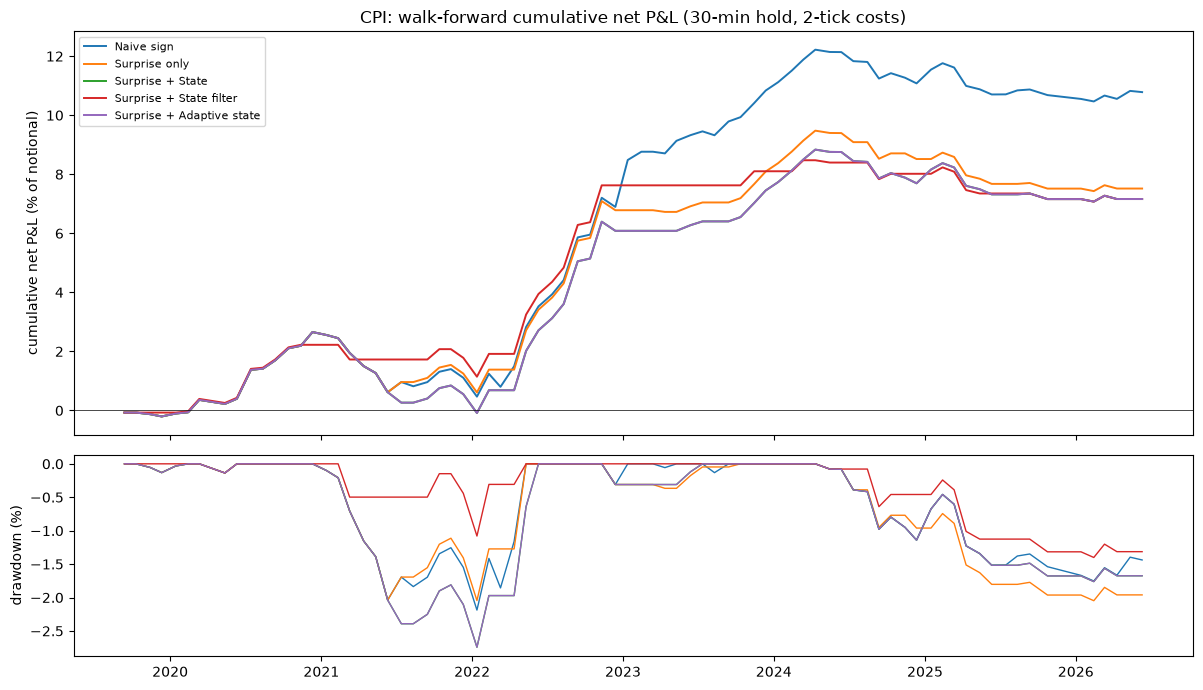

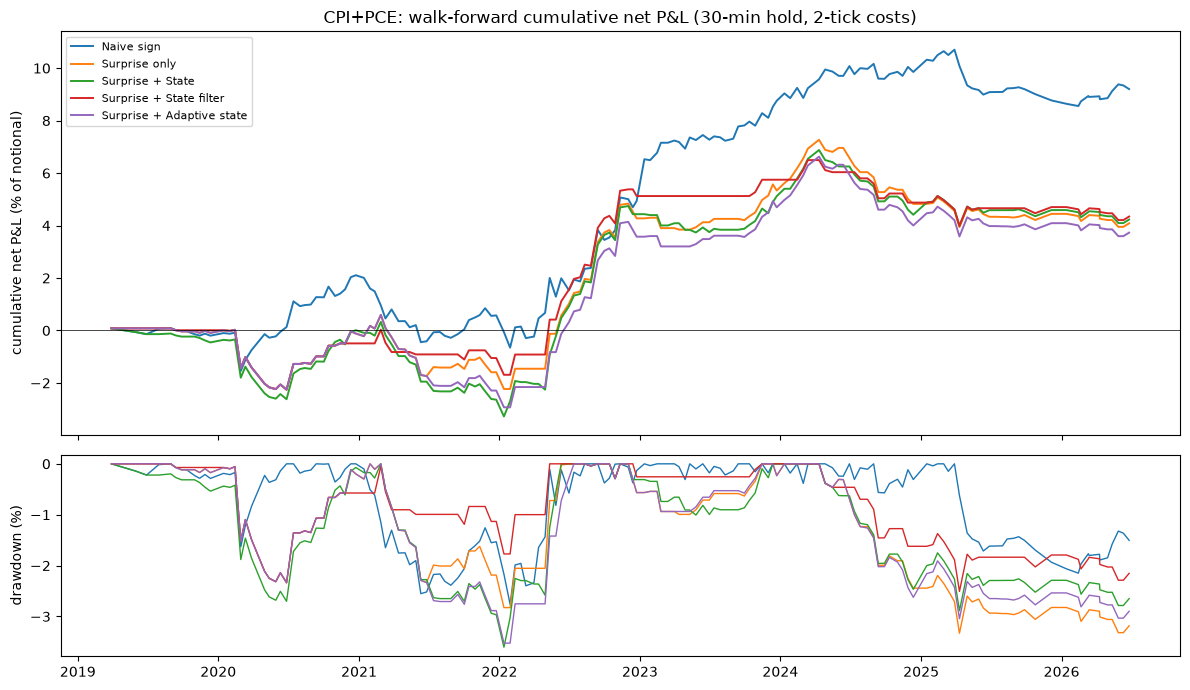

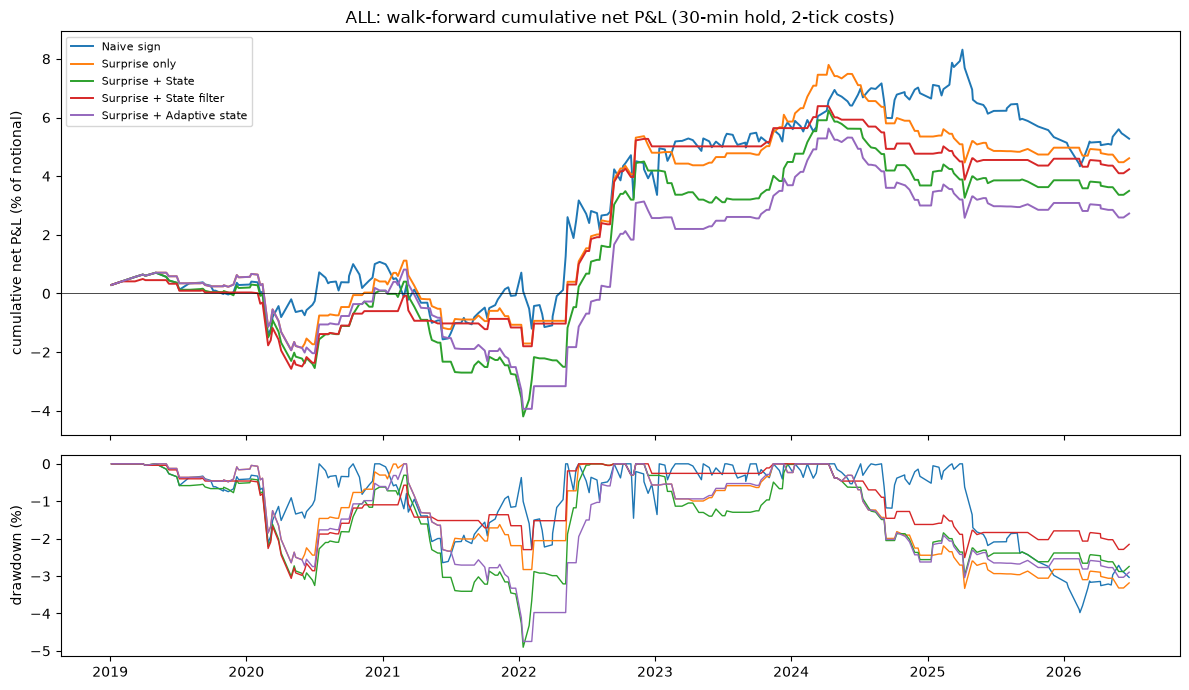

In [11]:
def plot_cum(uname, fname):
    fams = UNIVERSES[uname]
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    for i, name in enumerate(STRATS):
        cum, dd = wf.drawdown_series(universe(trades[name], fams), EVAL_START, EVAL_END)
        axes[0].plot(cum.index, cum.values, label=name, lw=1.4, c=f"C{i}")
        axes[1].plot(dd.index, dd.values, lw=1.0, c=f"C{i}")
    axes[0].axhline(0, c="k", lw=0.5)
    axes[0].set_ylabel("cumulative net P&L (% of notional)")
    axes[0].set_title(f"{uname}: walk-forward cumulative net P&L ({HOLD}-min hold, {SLIPPAGE_TICKS_RT:g}-tick costs)")
    axes[0].legend(fontsize=8)
    axes[1].set_ylabel("drawdown (%)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

for uname in UNIVERSES:
    plot_cum(uname, f"nb04b_{MARKET}_cum_pnl_{uname.replace('+', '_')}.png")

## 10. P&L by Year and by Volatility State

CPI: net P&L by calendar year (% of notional)


,Naive sign,Surprise only,Surprise + State,Surprise + State filter,Surprise + Adaptive state
timestamp_utc,,,,,
2019,-0.200,-0.200,-0.200,-0.070,-0.200
2020,2.860,2.860,2.860,2.300,2.860
2021,-1.550,-1.410,-2.100,-0.440,-2.100
2022,5.790,5.530,5.530,5.840,5.530
2023,3.940,1.310,1.370,0.480,1.370
2024,0.240,0.420,0.240,-0.090,0.240
2025,-0.400,-1.000,-0.540,-0.860,-0.540
2026,0.100,0.000,0.000,0.000,0.000


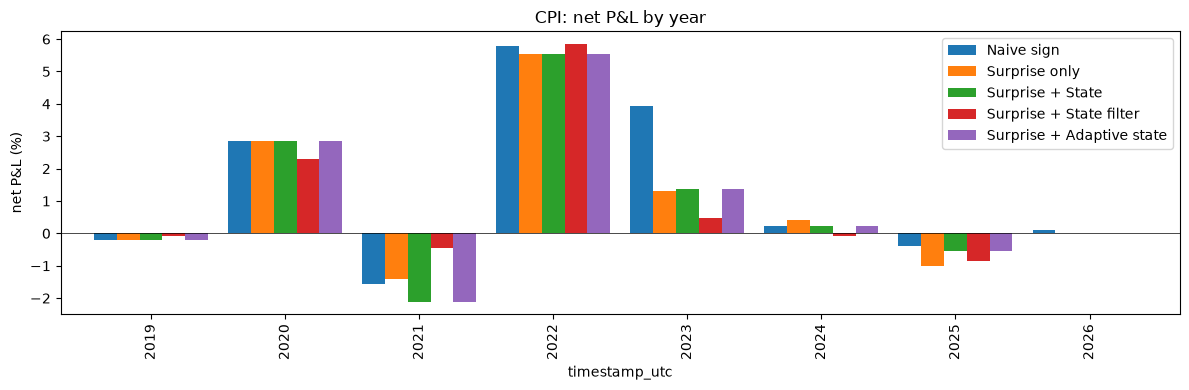

In [12]:
def by_year(tr, fams):
    t = universe(tr, fams)
    t = t[t["eligible"] & (t["timestamp_utc"] >= pd.Timestamp(EVAL_START, tz="UTC"))]
    return t.groupby(t["timestamp_utc"].dt.year)["net_bps"].sum() / 100

yearly = pd.DataFrame({name: by_year(trades[name], UNIVERSES["CPI"]) for name in STRATS})
print("CPI: net P&L by calendar year (% of notional)")
display(yearly.round(2))

ax = yearly.plot.bar(figsize=(12, 4), width=0.85)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("net P&L (%)"); ax.set_title("CPI: net P&L by year")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb04b_{MARKET}_cpi_pnl_by_year.png", dpi=150); plt.show()

In [13]:
# Where does the state model make or save money? CPI P&L by rv_20d tercile at the time of the release
bucket_of = ev.set_index("timestamp_utc")[f"{STATE}_bucket"].astype(str)
rows = []
for name in [BASE, STATE_MODEL, "Surprise + State filter"]:
    t = universe(trades[name], ["CPI"])
    t = t[t["eligible"] & (t["timestamp_utc"] >= pd.Timestamp(EVAL_START, tz="UTC"))].copy()
    t["bucket"] = t["timestamp_utc"].map(bucket_of)
    g = t.groupby("bucket")
    rows.append(pd.DataFrame({
        "strategy": name,
        "events": g.size(),
        "trades": g["position"].apply(lambda p: (p != 0).sum()),
        "hit_rate": g.apply(lambda d: (d.loc[d.position != 0, "net_bps"] > 0).mean()),
        "avg_net_bps_per_trade": g.apply(lambda d: d.loc[d.position != 0, "net_bps"].mean()),
        "total_net_pct": g["net_bps"].sum() / 100,
    }))
state_pnl = pd.concat(rows).reset_index().set_index(["strategy", "bucket"]).reindex(["Low", "Mid", "High"], level=1)
print(f"CPI P&L by {STATE} tercile")
display(state_pnl.round(2))

CPI P&L by rv_20d tercile


events  trades  hit_rate  avg_net_bps_per_trade  total_net_pct
strategy                bucket                                                                
Surprise only           Low         35      26     0.500                  1.370          0.360
                        Mid         19      16     0.810                 34.630          5.540
                        High        25      20     0.500                  8.100          1.620
Surprise + State        Low         35      25     0.480                 -1.140         -0.290
                        Mid         19      17     0.760                 31.690          5.390
                        High        25      22     0.500                  9.360          2.060
Surprise + State filter Low         35       0       NaN                    NaN          0.000
                        Mid         19      16     0.810                 34.630          5.540
                        High        25      20     0.500                  8.100          1.620

**How to read it.** If NB03 is right, the surprise-only strategy should earn little or lose money in **Low**-volatility CPI releases. The state models should avoid or shrink those trades, and keep most of the P&L in **Mid** and **High**.

## 11. Statistical Comparison: Does State Add Value?

- **Bootstrap Sharpe CI:** a moving-block bootstrap (3-month blocks) of each strategy's monthly returns.
- **Sharpe difference:** a *paired* bootstrap, resampling the same months for both strategies, of $\text{Sharpe}_{\text{state model}} - \text{Sharpe}_{\text{surprise only}}$.
- **Paired trade test:** a t-test on the per-release P&L difference.

In [14]:
rows = []
for uname, fams in UNIVERSES.items():
    for name in STRATS:
        (lo, mid, hi), p0 = wf.bootstrap_sharpe(universe(trades[name], fams), EVAL_START, EVAL_END, N_BOOT)
        rows.append(dict(universe=uname, strategy=name,
                         sharpe=perf[uname].loc[name, "sharpe_net"],
                         ci_5=lo, ci_95=hi, p_sharpe_le_0=p0))
sharpe_ci = pd.DataFrame(rows).set_index(["universe", "strategy"])
sharpe_ci.to_csv(RESULTS_DIR / f"nb04b_{MARKET}_sharpe_bootstrap.csv")
print("Net Sharpe with 90% block-bootstrap interval")
display(sharpe_ci.round(3))

Net Sharpe with 90% block-bootstrap interval


sharpe   ci_5  ci_95  p_sharpe_le_0
universe strategy                                                      
CPI      Naive sign                  1.003  0.366  1.660          0.008
         Surprise only               0.794  0.121  1.468          0.030
         Surprise + State            0.747  0.043  1.440          0.042
         Surprise + State filter     0.825  0.204  1.384          0.015
         Surprise + Adaptive state   0.747  0.043  1.440          0.042
CPI+PCE  Naive sign                  0.744  0.108  1.471          0.025
         Surprise only               0.344 -0.401  1.057          0.220
         Surprise + State            0.333 -0.415  1.003          0.223
         Surprise + State filter     0.398 -0.311  1.044          0.165
         Surprise + Adaptive state   0.310 -0.445  1.029          0.244
ALL      Naive sign                  0.381 -0.191  0.962          0.136
         Surprise only               0.369 -0.364  1.080          0.207
         Surprise + State            0.247 -0.482  0.916          0.287
         Surprise + State filter     0.366 -0.342  1.024          0.199
         Surprise + Adaptive state   0.207 -0.527  0.946          0.325

In [15]:
rows = []
for uname, fams in UNIVERSES.items():
    a = universe(trades[BASE], fams)
    for name in STRATS:
        if name == BASE:
            continue
        b = universe(trades[name], fams)
        obs, (lo, mid, hi), p = wf.bootstrap_sharpe_diff(a, b, EVAL_START, EVAL_END, N_BOOT)
        pt = wf.paired_trade_test(a, b, EVAL_START, EVAL_END)
        rows.append(dict(universe=uname, strategy=name, sharpe_diff_vs_surprise_only=obs,
                         diff_ci_5=lo, diff_ci_95=hi, p_diff_le_0=p,
                         mean_trade_diff_bps=pt["mean_diff_bps"], paired_t=pt["t_stat"],
                         events_with_different_pnl=pt["events_where_different"]))
comparison = pd.DataFrame(rows).set_index(["universe", "strategy"])
comparison.to_csv(RESULTS_DIR / f"nb04b_{MARKET}_state_vs_surprise_tests.csv")
print("Each strategy vs. Surprise only (positive = better than surprise only)")
display(comparison.round(3))

Each strategy vs. Surprise only (positive = better than surprise only)


sharpe_diff_vs_surprise_only  diff_ci_5  diff_ci_95  p_diff_le_0  mean_trade_diff_bps  paired_t  events_with_different_pnl
universe strategy                                                                                                                                             
CPI      Naive sign                                        0.209      0.011       0.444        0.041                4.134     1.636                         17
         Surprise + State                                 -0.047     -0.211       0.083        0.676               -0.450    -0.413                          5
         Surprise + State filter                           0.031     -0.299       0.330        0.466               -0.450    -0.254                         26
         Surprise + Adaptive state                        -0.047     -0.211       0.083        0.676               -0.450    -0.413                          5
CPI+PCE  Naive sign                                        0.400     -0.197       1.084        0.134                3.178     1.161                         94
         Surprise + State                                 -0.012     -0.225       0.166        0.569                0.090     0.084                         42
         Surprise + State filter                           0.054     -0.232       0.322        0.390                0.160     0.158                         48
         Surprise + Adaptive state                        -0.034     -0.164       0.072        0.661               -0.221    -0.414                          5
ALL      Naive sign                                        0.012     -0.575       0.591        0.487                0.272     0.120                        164
         Surprise + State                                 -0.122     -0.326       0.040        0.895               -0.454    -0.521                         50
         Surprise + State filter                          -0.003     -0.283       0.263        0.540               -0.154    -0.224                         53
         Surprise + Adaptive state                        -0.162     -0.338      -0.008        0.959               -0.769    -1.503                          9

**How to read it.** `p_diff_le_0` is the bootstrap probability that the strategy is **not** better than surprise only. Below 0.05 is convincing evidence; 0.05–0.20 is suggestive; above 0.20 means the difference could easily be noise.

## 12. Robustness

### 12.1 Transaction costs

strategy,Naive sign,Surprise + State,Surprise + State filter,Surprise only
ticks_rt,,,,
0,1.030,0.840,0.910,1.020
1,1.020,0.750,0.860,0.860
2,1.000,0.750,0.820,0.790
4,0.980,0.700,0.800,0.760
6,0.950,0.660,0.800,0.750
8,0.930,0.600,0.870,0.810


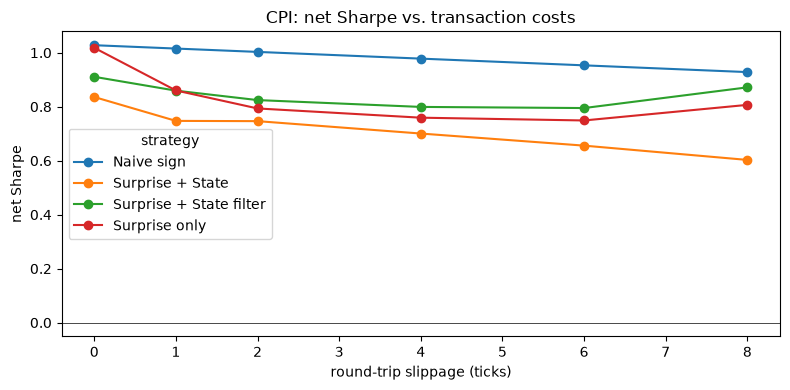

Highest tested cost (ticks) with positive Sharpe:


,max_ticks_positive_sharpe
strategy,
Naive sign,8
Surprise + State,8
Surprise + State filter,8
Surprise only,8


In [16]:
TICKS = [0, 1, 2, 4, 6, 8]
rob_specs = [s for s in SPECS if s.name in ("Naive sign", BASE, STATE_MODEL, "Surprise + State filter")]
rows = []
for tk in TICKS:
    tr_tk = run_all(rob_specs, ticks=tk, families=["CPI"])
    for name, t in tr_tk.items():
        p = wf.performance(t, EVAL_START, EVAL_END, name)
        rows.append(dict(ticks_rt=tk, strategy=name, sharpe_net=p["sharpe_net"],
                         avg_net_bps=p["avg_net_bps"], trades=p["trades"], ann_return_pct=p["ann_return_pct"]))
cost_sens = pd.DataFrame(rows)
cost_sens.to_csv(RESULTS_DIR / f"nb04b_{MARKET}_cost_sensitivity.csv", index=False)
display(cost_sens.pivot(index="ticks_rt", columns="strategy", values="sharpe_net").round(2))

ax = cost_sens.pivot(index="ticks_rt", columns="strategy", values="sharpe_net").plot(marker="o", figsize=(8, 4))
ax.axhline(0, c="k", lw=0.5); ax.set_xlabel("round-trip slippage (ticks)"); ax.set_ylabel("net Sharpe")
ax.set_title("CPI: net Sharpe vs. transaction costs")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb04b_{MARKET}_cost_sensitivity.png", dpi=150); plt.show()

breakeven = cost_sens[cost_sens["sharpe_net"] > 0].groupby("strategy")["ticks_rt"].max()
print("Highest tested cost (ticks) with positive Sharpe:")
display(breakeven.to_frame("max_ticks_positive_sharpe"))

### 12.2 Entry latency and holding period

Does the edge survive if the trader reacts 1, 2 or 5 minutes later? Which holding period works best? *(These results are **not** used to change the base case, since that would be data mining.)*

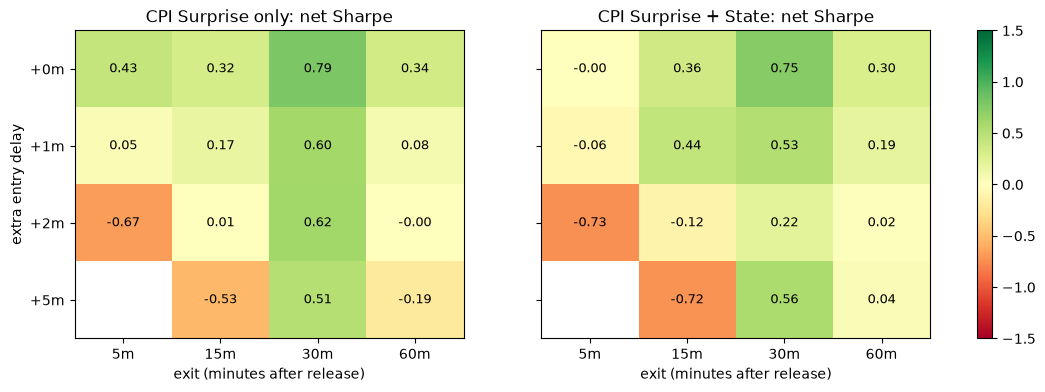

In [17]:
rows = []
grid_specs = [s for s in SPECS if s.name in (BASE, STATE_MODEL)]
for L in ENTRY_LAGS:
    for H in HOLDS:
        col = wf.trade_col(L, H)
        if col not in ev.columns:
            continue
        tr_g = run_all(grid_specs, target=col, families=["CPI"])
        for name, t in tr_g.items():
            p = wf.performance(t, EVAL_START, EVAL_END, name)
            rows.append(dict(entry_lag=L, hold=H, strategy=name, sharpe_net=p["sharpe_net"],
                             avg_net_bps=p["avg_net_bps"], trades=p["trades"]))
grid = pd.DataFrame(rows)
grid.to_csv(RESULTS_DIR / f"nb04b_{MARKET}_latency_holding_grid.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, name in zip(axes, [BASE, STATE_MODEL]):
    m = grid[grid.strategy == name].pivot(index="entry_lag", columns="hold", values="sharpe_net")
    im = ax.imshow(m.values, cmap="RdYlGn", vmin=-1.5, vmax=1.5, aspect="auto")
    ax.set_xticks(range(m.shape[1])); ax.set_xticklabels([f"{h}m" for h in m.columns])
    ax.set_yticks(range(m.shape[0])); ax.set_yticklabels([f"+{l}m" for l in m.index])
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            if np.isfinite(m.values[i, j]):
                ax.text(j, i, f"{m.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(f"CPI {name}: net Sharpe"); ax.set_xlabel("exit (minutes after release)")
axes[0].set_ylabel("extra entry delay")
plt.colorbar(im, ax=axes, fraction=0.03)
plt.savefig(FIGURES_DIR / f"nb04b_{MARKET}_latency_holding_grid.png", dpi=150, bbox_inches="tight"); plt.show()

### 12.3 Estimation window and trade threshold

In [18]:
rows = []
variants = {
    "expanding, thr=1.0 (base)": dict(window=None, threshold_mult=1.0),
    "rolling 60 events, thr=1.0": dict(window=60, threshold_mult=1.0),
    "rolling 36 events, thr=1.0": dict(window=36, threshold_mult=1.0),
    "expanding, thr=0 (always trade)": dict(window=None, threshold_mult=0.0),
    "expanding, thr=2.0": dict(window=None, threshold_mult=2.0),
}
for vname, kw in variants.items():
    specs_v = [wf.StrategySpec(BASE, "surprise", min_train=MIN_TRAIN, **kw),
               wf.StrategySpec(STATE_MODEL, "state", state=STATE, min_train=MIN_TRAIN, **kw)]
    for uname in ["CPI", "ALL"]:
        tr_v = run_all(specs_v, families=UNIVERSES[uname])
        for name, t in tr_v.items():
            p = wf.performance(t, EVAL_START, EVAL_END, name)
            rows.append(dict(variant=vname, universe=uname, strategy=name,
                             sharpe_net=p["sharpe_net"], trades=p["trades"], avg_net_bps=p["avg_net_bps"]))
window_sens = pd.DataFrame(rows)
window_sens.to_csv(RESULTS_DIR / f"nb04b_{MARKET}_window_threshold_sensitivity.csv", index=False)
display(window_sens.pivot_table(index="variant", columns=["universe", "strategy"], values="sharpe_net").round(2))

universe                                     ALL                            CPI              
strategy                        Surprise + State Surprise only Surprise + State Surprise only
variant                                                                                      
expanding, thr=0 (always trade)            0.260         0.700            0.930         1.000
expanding, thr=1.0 (base)                  0.250         0.370            0.750         0.790
expanding, thr=2.0                         0.320         0.400            0.720         0.740
rolling 36 events, thr=1.0                 0.500         0.680            0.670         0.810
rolling 60 events, thr=1.0                 0.180         0.370            0.540         0.790

**How to read it.** A robust result keeps the **same ranking** between surprise only and surprise + state across most rows. If the state model only wins in one variant, the improvement is fragile.

## 13. What Did the Adaptive Model Choose?

The adaptive model uses no full-sample knowledge. It picks a state only when the **training data** shows $|t| \ge 2$ on the interaction. Its choices show whether the `rv_20d` effect was detectable in real time.

In [19]:
ad = trades["Surprise + Adaptive state"]
ad = ad[ad["eligible"] & (ad["timestamp_utc"] >= pd.Timestamp(EVAL_START, tz="UTC"))].copy()
ad["year"] = ad["timestamp_utc"].dt.year
usage = ad.groupby(["event_type", "used_state"]).size().unstack(fill_value=0)
print("How often each state was used (evaluation period):")
display(usage)

cpi_ad = ad[ad.event_type == "CPI"]
print("\nCPI: state chosen by year")
display(cpi_ad.groupby(["year", "used_state"]).size().unstack(fill_value=0))

How often each state was used (evaluation period):


used_state,none,overnight_ret,prev_x,rv_20d,rv_pre_1d
event_type,,,,,
CPI,31,12,2,34,0
NFP,79,0,0,1,4
PCE,82,0,0,0,0



CPI: state chosen by year


used_state,none,overnight_ret,prev_x,rv_20d
year,,,,
2019,4,0,0,0
2020,11,0,0,0
2021,11,0,1,0
2022,5,0,1,6
2023,0,0,0,12
2024,0,0,0,12
2025,0,6,0,4
2026,0,6,0,0


## 14. Final Comparison

In [20]:
FINAL_COLS = ["trades", "hit_rate", "avg_net_bps", "ann_return_pct", "ann_vol_pct",
              "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
final = pd.concat({u: perf[u][FINAL_COLS] for u in UNIVERSES}, names=["universe", "strategy"])
final = final.join(sharpe_ci[["ci_5", "ci_95"]]).join(
    comparison[["sharpe_diff_vs_surprise_only", "p_diff_le_0"]], how="left")
final.to_csv(RESULTS_DIR / f"nb04b_{MARKET}_final_comparison.csv")
display(final.round(3))

trades  hit_rate  avg_net_bps  ann_return_pct  ann_vol_pct  sharpe_net  max_dd_pct  t_stat_trade  profit_factor   ci_5  ci_95  sharpe_diff_vs_surprise_only  \
universe strategy                                                                                                                                                                                 
CPI      Naive sign                     79     0.582       13.649           1.438        1.433       1.003      -2.188         2.761          2.470  0.366  1.660                         0.209   
         Surprise only                  62     0.581       12.124           1.002        1.263       0.794      -2.047         2.194          2.200  0.121  1.468                           NaN   
         Surprise + State               64     0.562       11.190           0.955        1.279       0.747      -2.743         2.059          2.062  0.043  1.440                        -0.047   
         Surprise + State filter        36     0.639       19.893           0.955        1.158       0.825      -1.401         2.342          3.017  0.204  1.384                         0.031   
         Surprise + Adaptive state      64     0.562       11.190           0.955        1.279       0.747      -2.743         2.059          2.062  0.043  1.440                        -0.047   
CPI+PCE  Naive sign                    161     0.571        5.715           1.227        1.649       0.744      -2.761         1.915          1.574  0.108  1.471                         0.400   
         Surprise only                 122     0.484        3.349           0.545        1.583       0.344      -3.329         0.959          1.290 -0.401  1.057                           NaN   
         Surprise + State              134     0.463        3.157           0.564        1.696       0.333      -3.604         0.965          1.277 -0.415  1.003                        -0.012   
         Surprise + State filter        74     0.514        5.870           0.579        1.456       0.398      -2.507         1.105          1.451 -0.311  1.044                         0.054   
         Surprise + Adaptive state     124     0.476        3.008           0.497        1.602       0.310      -3.524         0.869          1.256 -0.445  1.029                        -0.034   
ALL      Naive sign                    245     0.535        2.154           0.704        1.846       0.381      -3.977         0.889          1.178 -0.191  0.962                         0.012   
         Surprise only                 138     0.507        3.341           0.615        1.667       0.369      -3.329         1.062          1.302 -0.364  1.080                           NaN   
         Surprise + State              157     0.471        2.229           0.467        1.888       0.247      -4.902         0.755          1.190 -0.482  0.916                        -0.122   
         Surprise + State filter        85     0.518        4.982           0.565        1.544       0.366      -3.062         1.057          1.393 -0.342  1.024                        -0.003   
         Surprise + Adaptive state     143     0.483        1.906           0.363        1.756       0.207      -4.748         0.610          1.159 -0.527  0.946                        -0.162   

                                    p_diff_le_0  
universe strategy                                
CPI      Naive sign                       0.041  
         Surprise only                      NaN  
         Surprise + State                 0.676  
         Surprise + State filter          0.466  
         Surprise + Adaptive state        0.676  
CPI+PCE  Naive sign                       0.134  
         Surprise only                      NaN  
         Surprise + State                 0.569  
         Surprise + State filter          0.390  
         Surprise + Adaptive state        0.661  
ALL      Naive sign                       0.487  
         Surprise only                      NaN  
         Surprise + 

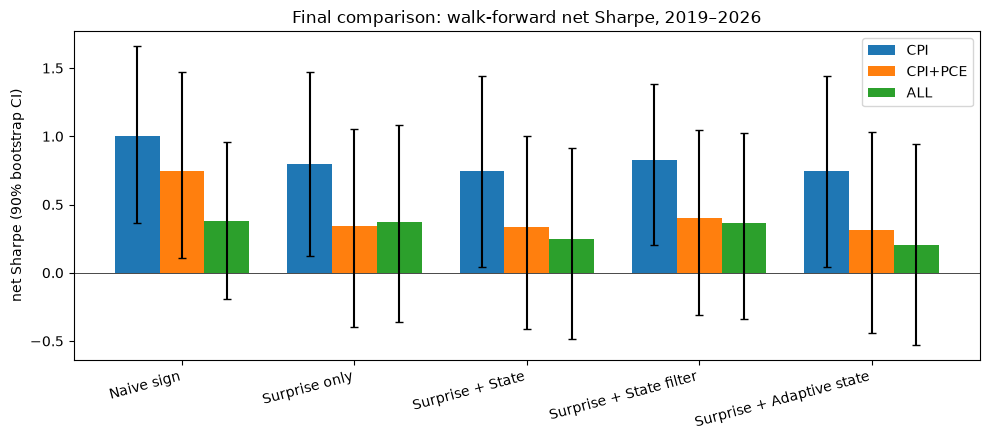

In [21]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(STRATS))
w = 0.26
for k, uname in enumerate(UNIVERSES):
    s = sharpe_ci.loc[uname].reindex(STRATS)
    ax.bar(x + (k - 1) * w, s["sharpe"], w, label=uname,
           yerr=[s["sharpe"] - s["ci_5"], s["ci_95"] - s["sharpe"]], capsize=3)
ax.axhline(0, c="k", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(STRATS, rotation=15, ha="right")
ax.set_ylabel("net Sharpe (90% bootstrap CI)")
ax.set_title("Final comparison: walk-forward net Sharpe, 2019–2026")
ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb04b_{MARKET}_final_sharpe_comparison.png", dpi=150); plt.show()

### 14.1 Automatic results summary

In [22]:
c = perf["CPI"]; a = perf["ALL"]
best_cpi = c["sharpe_net"].idxmax()
print("=" * 80)
print("NOTEBOOK 04 SUMMARY (walk-forward, net of costs)")
print("=" * 80)
print(f"Evaluation: {EVAL_START} to {EVAL_END} | entry = first post-release bar | hold = {HOLD} min | "
      f"costs = {SLIPPAGE_TICKS_RT:g} ticks + ${COMMISSION_RT_USD} RT")
print("\nCPI universe:")
for name in STRATS:
    r = c.loc[name]
    print(f"  {name:<28s} trades={int(r.trades):>3d}  hit={r.hit_rate:5.1%}  avg net={r.avg_net_bps:6.2f} bps  "
          f"ann ret={r.ann_return_pct:6.2f}%  Sharpe={r.sharpe_net:5.2f}  maxDD={r.max_dd_pct:6.2f}%")
print("\nALL (CPI+PCE+NFP) universe:")
for name in STRATS:
    r = a.loc[name]
    print(f"  {name:<28s} trades={int(r.trades):>3d}  Sharpe={r.sharpe_net:5.2f}  ann ret={r.ann_return_pct:6.2f}%")
print(f"\nBest CPI strategy by net Sharpe: {best_cpi}")
cmp = comparison.loc["CPI"]
for name in cmp.index:
    print(f"  {name:<28s} Sharpe diff vs surprise only = {cmp.loc[name, 'sharpe_diff_vs_surprise_only']:+.2f}"
          f"  (P[not better] = {cmp.loc[name, 'p_diff_le_0']:.2f})")
print("\nSaved: results/nb04_*.csv and figures/nb04_*.png")

NOTEBOOK 04 SUMMARY (walk-forward, net of costs)
Evaluation: 2019-01-01 to 2026-06-30 | entry = first post-release bar | hold = 30 min | costs = 2 ticks + $4.5 RT

CPI universe:
  Naive sign                   trades= 79  hit=58.2%  avg net= 13.65 bps  ann ret=  1.44%  Sharpe= 1.00  maxDD= -2.19%
  Surprise only                trades= 62  hit=58.1%  avg net= 12.12 bps  ann ret=  1.00%  Sharpe= 0.79  maxDD= -2.05%
  Surprise + State             trades= 64  hit=56.2%  avg net= 11.19 bps  ann ret=  0.95%  Sharpe= 0.75  maxDD= -2.74%
  Surprise + State filter      trades= 36  hit=63.9%  avg net= 19.89 bps  ann ret=  0.95%  Sharpe= 0.82  maxDD= -1.40%
  Surprise + Adaptive state    trades= 64  hit=56.2%  avg net= 11.19 bps  ann ret=  0.95%  Sharpe= 0.75  maxDD= -2.74%

ALL (CPI+PCE+NFP) universe:
  Naive sign                   trades=245  Sharpe= 0.38  ann ret=  0.70%
  Surprise only                trades=138  Sharpe= 0.37  ann ret=  0.61%
  Surprise + State             trades=157  Sharpe= 0

## 15. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Is there a tradeable edge after costs?** Report the surprise-only CPI Sharpe, the average net bps per trade and the hit rate. Compare with the naive sign rule: if they are similar, estimation adds little beyond the economic prior.

**2. Does state conditioning improve it out of sample?** Compare surprise + state, the state filter and the adaptive model against surprise only, using the Sharpe difference and its bootstrap p-value.
- The **adaptive** result is the cleanest test, since it uses no full-sample information.
- If only the NB03-selected models win, part of the improvement may come from **selection bias**.

**3. Robustness.** How many ticks of cost can the strategy absorb? Does it survive a 1–2 minute entry delay? Is the ranking stable across windows and thresholds?

**4. CPI vs broader universe.** Does adding PCE and NFP help diversification, or dilute the CPI signal?

**5. Final verdict for the project.** Surprise only vs surprise + state: which one would you recommend, and how confident are you?

**Caveats.** About 90 CPI trades over 7.5 years is a small sample. Returns are per unit of notional before leverage. Execution in the first minute after a release can be worse than modelled. And the post-2021 inflation regime dominates the sample.

# 16. Peer Comparison: Our Results in the DTW Project's Format

Another team (Jack, Matthieu, Stefan) built an intraday ES strategy on the same idea: trade 30-minute windows after scheduled US macro releases. Their signal is different. They match the **shape of the price path** before entry to similar historical reactions using Dynamic Time Warping (DTW). Their reported results (2018–2026, one contract):

| | Total % | Vol | Sharpe | Max DD | Beta |
|---|---|---|---|---|---|
| Net | 18.597% | 3.020% | 0.613 | −4.928% | −0.005 |
| Gross | 22.381% | 3.024% | 0.737 | −4.575% | −0.005 |
| Buy + hold | 100.741% | 17.644% | 0.568 | −43.136% | — |

They trade 8 release families, about 185 trades a year, and are in the market 1.4% of the time.

To compare fairly, this section recomputes **our** strategies with **their metric definitions**:

- **Daily return series.** Each trading day's return is the sum of that day's trade returns on **one contract** (constant notional, not compounded), and 0 on days without a trade.
- **Total %.** The sum of daily returns: the cumulative P&L of one contract, as a % of notional.
- **Vol and Sharpe.** Annualised from daily returns with $\sqrt{252}$. This differs slightly from Section 8, which used monthly returns.
- **Max DD.** The largest peak-to-trough fall of the cumulative P&L curve.
- **Beta.** The slope of the daily strategy return on the daily buy-and-hold ES return. A value near 0 means the strategy is **market-neutral**.
- **Two benchmarks:**
  - **Buy + hold:** long ES every day of the evaluation period (roll-adjusted). Total and drawdown follow the compounded price path.
  - **Always long, same windows:** long in **exactly the windows the strategy traded**, with the same costs. The gap between the strategy and this line is the value of predicting the **direction** correctly, rather than just being exposed during releases.

## 16.1 Daily return series and benchmarks

In [23]:
daily_close = sc.build_daily_close(es_adj)
_in = (daily_close.index >= pd.Timestamp(EVAL_START)) & (daily_close.index <= pd.Timestamp(EVAL_END))
trading_days = daily_close.index[_in]
N_YEARS = (trading_days[-1] - trading_days[0]).days / 365.25
MIN_PER_DAY = 23 * 60                       # ES trades ~23 hours a day
bh_daily = wf.buy_hold_daily(daily_close, trading_days)

def in_eval(tr):
    ts = pd.to_datetime(tr["timestamp_utc"], utc=True)
    return tr[(ts >= pd.Timestamp(EVAL_START, tz="UTC")) & (ts <= pd.Timestamp(EVAL_END, tz="UTC"))]

def peer_row(tr, col="net_bps"):
    d = wf.daily_returns(tr, trading_days, col)
    n = int((in_eval(tr).query("eligible")["position"] != 0).sum())
    tim = n * HOLD / (len(trading_days) * MIN_PER_DAY) * 100
    return wf.peer_metrics(d, bh_daily, trades_per_year=n / N_YEARS, minutes_in_market=tim)

print(f"Trading days: {len(trading_days)}  ({trading_days[0].date()} to {trading_days[-1].date()}, {N_YEARS:.2f} years)")
print("Buy + hold check:", {k: round(v, 3) for k, v in wf.peer_metrics(bh_daily, bh_daily, compound=True).items()})

Trading days: 1834  (2019-01-02 to 2026-06-30, 7.49 years)
Buy + hold check: {'total_pct': np.float64(347.891), 'vol_pct': np.float64(23.679), 'sharpe': np.float64(0.989), 'max_dd_pct': np.float64(-38.28), 'beta': np.float64(1.0), 'corr': np.float64(1.0)}


## 16.2 Headline table in the peer format

The same rows as the peer slide (Net, Gross, Buy + hold), plus the exposure-matched benchmark, for our headline strategy on each universe.

In [24]:
PEER_COLS = ["total_pct", "vol_pct", "sharpe", "max_dd_pct", "beta", "trades_per_year", "time_in_market_pct"]

def peer_block(strategy, uname):
    tr = universe(trades[strategy], UNIVERSES[uname])
    rows = {
        "Net": peer_row(tr, "net_bps"),
        "Gross": peer_row(tr, "gross_bps"),
        "Always long, same windows (net)": peer_row(wf.always_long(tr), "net_bps"),
        "Buy + hold": {**wf.peer_metrics(bh_daily, bh_daily, compound=True), "trades_per_year": np.nan, "time_in_market_pct": 100.0},
    }
    return pd.DataFrame(rows).T[PEER_COLS]

peer_tables = {}
for strategy, uname in [("Surprise only", "CPI"), ("Naive sign", "CPI"),
                        ("Surprise + State filter", "CPI"), ("Surprise only", "ALL")]:
    key = f"{strategy} | {uname}"
    peer_tables[key] = peer_block(strategy, uname)
    print(f"\n=== {key} ===")
    display(peer_tables[key].round(3))

pd.concat(peer_tables, names=["strategy | universe", "row"]).to_csv(RESULTS_DIR / f"nb04b_{MARKET}_peer_format_tables.csv")


=== Surprise only | CPI ===


,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct
Net,7.517,1.307,0.790,-2.047,-0.001,8.277,0.073
Gross,7.844,1.312,0.821,-2.005,-0.001,8.277,0.073
"Always long, same windows (net)",-5.449,1.316,-0.569,-5.741,0.009,8.277,0.073
Buy + hold,347.891,23.679,0.989,-38.280,1.000,NaN,100.000



=== Naive sign | CPI ===


,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct
Net,10.783,1.505,0.985,-2.188,-0.001,10.546,0.094
Gross,11.183,1.510,1.017,-2.122,-0.001,10.546,0.094
"Always long, same windows (net)",-1.908,1.514,-0.173,-4.086,0.009,10.546,0.094
Buy + hold,347.891,23.679,0.989,-38.280,1.000,NaN,100.000



=== Surprise + State filter | CPI ===


,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct
Net,7.161,1.201,0.819,-1.401,-0.001,4.806,0.043
Gross,7.356,1.206,0.838,-1.369,-0.001,4.806,0.043
"Always long, same windows (net)",-4.334,1.210,-0.492,-5.116,0.008,4.806,0.043
Buy + hold,347.891,23.679,0.989,-38.280,1.000,NaN,100.000



=== Surprise only | ALL ===


,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct
Net,4.611,1.610,0.393,-3.329,-0.001,18.423,0.164
Gross,5.385,1.613,0.459,-3.256,-0.001,18.423,0.164
"Always long, same windows (net)",-7.625,1.616,-0.648,-8.579,0.009,18.423,0.164
Buy + hold,347.891,23.679,0.989,-38.280,1.000,NaN,100.000


## 16.3 All strategies and universes (net, peer metrics)

In [25]:
rows = []
for uname, fams in UNIVERSES.items():
    for name in STRATS:
        r = peer_row(universe(trades[name], fams))
        rows.append({"universe": uname, "strategy": name, **r})
    r = peer_row(wf.always_long_all(universe(trades[BASE], fams)))
    rows.append({"universe": uname, "strategy": "Always long, all release windows", **r})
peer_all = pd.DataFrame(rows).set_index(["universe", "strategy"])[PEER_COLS]
peer_all.to_csv(RESULTS_DIR / f"nb04b_{MARKET}_peer_metrics_all.csv")
display(peer_all.round(3))

total_pct  vol_pct  sharpe  max_dd_pct   beta  trades_per_year  time_in_market_pct
universe strategy                                                                                                            
CPI      Naive sign                           10.783    1.505   0.985      -2.188 -0.001           10.546               0.094
         Surprise only                         7.517    1.307   0.790      -2.047 -0.001            8.277               0.073
         Surprise + State                      7.162    1.320   0.745      -2.743 -0.001            8.544               0.076
         Surprise + State filter               7.161    1.201   0.819      -1.401 -0.001            4.806               0.043
         Surprise + Adaptive state             7.162    1.320   0.745      -2.743 -0.001            8.544               0.076
         Always long, all release windows     -1.908    1.514  -0.173      -4.086  0.009           10.546               0.094
CPI+PCE  Naive sign                            9.202    1.795   0.704      -2.761 -0.002           21.493               0.191
         Surprise only                         4.085    1.579   0.355      -3.329 -0.002           16.287               0.145
         Surprise + State                      4.230    1.624   0.358      -3.604 -0.000           17.889               0.159
         Surprise + State filter               4.344    1.459   0.409      -2.507 -0.002            9.879               0.088
         Surprise + Adaptive state             3.730    1.590   0.322      -3.524 -0.001           16.554               0.147
         Always long, all release windows     -3.137    1.802  -0.239      -5.035  0.011           21.493               0.191
ALL      Naive sign                            5.278    2.199   0.330      -3.977 -0.004           32.707               0.290
         Surprise only                         4.611    1.610   0.393      -3.329 -0.001           18.423               0.164
         Surprise + State                      3.500    1.716   0.280      -4.902  0.001           20.959               0.186
         Surprise + State filter               4.235    1.486   0.392      -3.062 -0.001           11.347               0.101
         Surprise + Adaptive state             2.726    1.653   0.227      -4.748 -0.001           19.090               0.170
         Always long, all release windows     -2.481    2.202  -0.155      -8.998  0.014           32.707               0.290

## 16.4 Side by side with the peer project

In [26]:
peer = pd.DataFrame({
    "Peer DTW, net (8 families)":   dict(total_pct=18.597, vol_pct=3.020, sharpe=0.613, max_dd_pct=-4.928, beta=-0.005, trades_per_year=185, time_in_market_pct=1.4),
    "Peer DTW, gross":              dict(total_pct=22.381, vol_pct=3.024, sharpe=0.737, max_dd_pct=-4.575, beta=-0.005, trades_per_year=185, time_in_market_pct=1.4),
    "Peer buy + hold (2018-2026)":  dict(total_pct=100.741, vol_pct=17.644, sharpe=0.568, max_dd_pct=-43.136, beta=np.nan, trades_per_year=np.nan, time_in_market_pct=100.0),
}).T

ours = pd.DataFrame({
    "Ours: Surprise only, CPI, net":         peer_tables["Surprise only | CPI"].loc["Net"],
    "Ours: Surprise only, CPI, gross":       peer_tables["Surprise only | CPI"].loc["Gross"],
    "Ours: Naive sign, CPI, net":            peer_tables["Naive sign | CPI"].loc["Net"],
    "Ours: State filter, CPI, net":          peer_tables["Surprise + State filter | CPI"].loc["Net"],
    "Ours: Surprise only, ALL (3 fam.), net": peer_tables["Surprise only | ALL"].loc["Net"],
    f"Ours: buy + hold ({EVAL_START[:4]}-{EVAL_END[:4]})": peer_tables["Surprise only | CPI"].loc["Buy + hold"],
}).T

side = pd.concat([peer, ours])[PEER_COLS]
# Per-trade edge: total return / number of trades (bps)
side["net_bps_per_trade"] = side["total_pct"] * 100 / (side["trades_per_year"] * np.where(side.index.str.startswith("Peer"), 8.5, N_YEARS))
side.to_csv(RESULTS_DIR / f"nb04b_{MARKET}_peer_side_by_side.csv")
display(side.round(3))

,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct,net_bps_per_trade
"Peer DTW, net (8 families)",18.597,3.020,0.613,-4.928,-0.005,185.000,1.400,1.183
"Peer DTW, gross",22.381,3.024,0.737,-4.575,-0.005,185.000,1.400,1.423
Peer buy + hold (2018-2026),100.741,17.644,0.568,-43.136,NaN,NaN,100.000,NaN
"Ours: Surprise only, CPI, net",7.517,1.307,0.790,-2.047,-0.001,8.277,0.073,12.124
"Ours: Surprise only, CPI, gross",7.844,1.312,0.821,-2.005,-0.001,8.277,0.073,12.651
"Ours: Naive sign, CPI, net",10.783,1.505,0.985,-2.188,-0.001,10.546,0.094,13.649
"Ours: State filter, CPI, net",7.161,1.201,0.819,-1.401,-0.001,4.806,0.043,19.893
"Ours: Surprise only, ALL (3 fam.), net",4.611,1.610,0.393,-3.329,-0.001,18.423,0.164,3.341
Ours: buy + hold (2019-2026),347.891,23.679,0.989,-38.280,1.000,NaN,100.000,NaN


**How to read it.**
- **Sharpe** is the fair comparison: it is risk-adjusted and does not depend on how often a strategy trades.
- **Total %** and **Vol** scale with the number of trades. The peer trades about 185 times a year against our 7–11, so their totals are naturally larger. Both would be scaled to a risk target with leverage in practice.
- **`net_bps_per_trade`** measures the edge per trade. A larger number means more room before costs erase the profit.
- **Beta ≈ 0** means neither strategy is simply a disguised long-equity bet.
- The periods differ slightly: the peer covers 2018–2026, and we cover 2019–2026 because 2016–2018 is our training window.

## 16.5 Cumulative P&L in the peer chart format

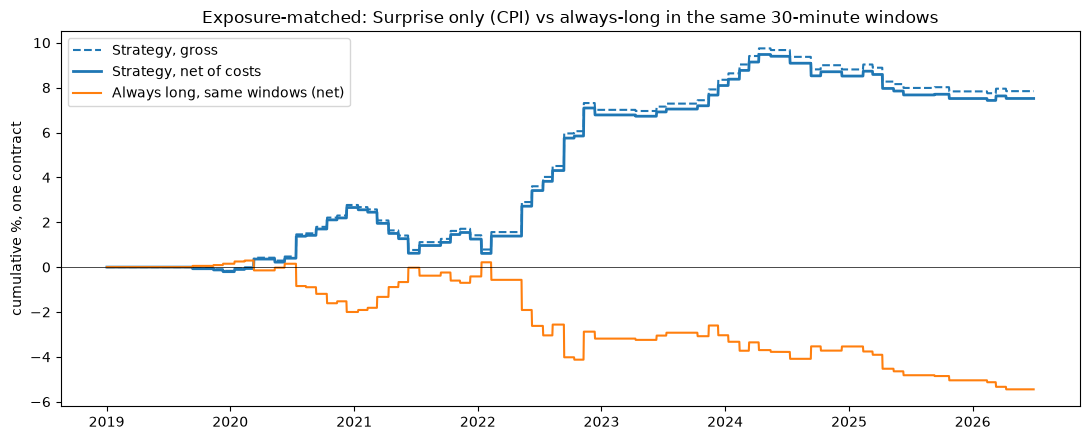

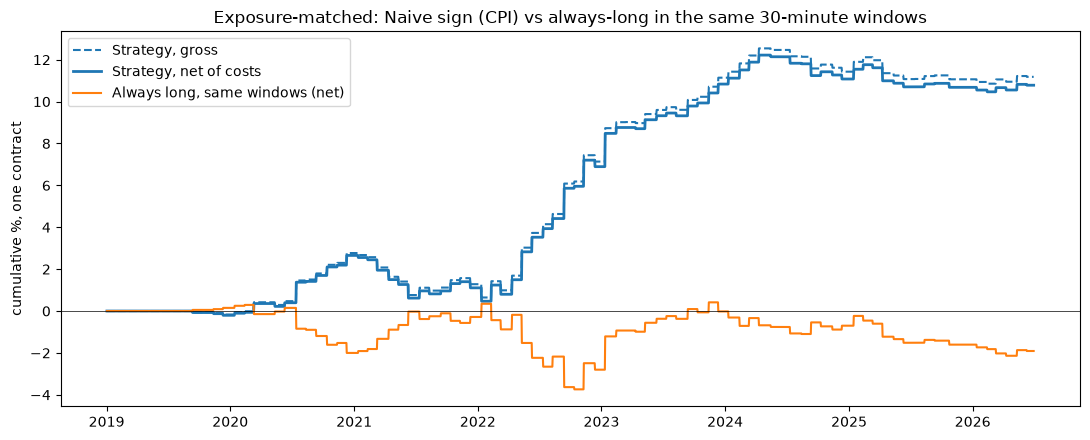

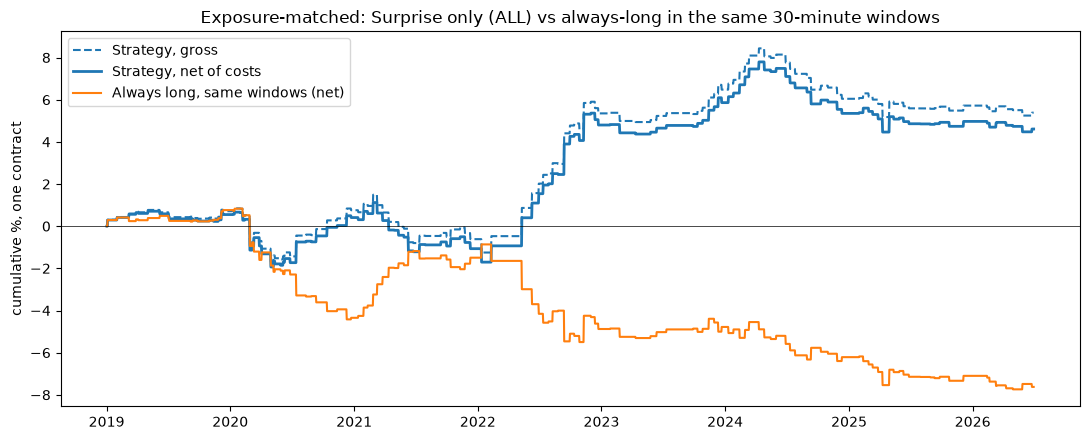

In [27]:
def peer_chart(strategy, uname, fname):
    tr = universe(trades[strategy], UNIVERSES[uname])
    lines = {
        "Strategy, gross": (wf.daily_returns(tr, trading_days, "gross_bps"), dict(ls="--", c="C0")),
        "Strategy, net of costs": (wf.daily_returns(tr, trading_days, "net_bps"), dict(ls="-", c="C0", lw=2)),
        "Always long, same windows (net)": (wf.daily_returns(wf.always_long(tr), trading_days, "net_bps"), dict(c="C1")),
    }
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for lab, (d, kw) in lines.items():
        ax.plot(d.index, d.cumsum() * 100, label=lab, **kw)
    ax.axhline(0, c="k", lw=0.5)
    ax.set_ylabel("cumulative %, one contract")
    ax.set_title(f"Exposure-matched: {strategy} ({uname}) vs always-long in the same 30-minute windows")
    ax.legend()
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

peer_chart("Surprise only", "CPI", f"nb04b_{MARKET}_peer_chart_CPI_surprise_only.png")
peer_chart("Naive sign", "CPI", f"nb04b_{MARKET}_peer_chart_CPI_naive.png")
peer_chart("Surprise only", "ALL", f"nb04b_{MARKET}_peer_chart_ALL_surprise_only.png")

## 16.6 Summary of the peer comparison

In [28]:
o = peer_tables["Surprise only | CPI"]
n = peer_tables["Naive sign | CPI"]
a = peer_tables["Surprise only | ALL"]
print("=" * 80)
print("PEER COMPARISON SUMMARY (daily metrics, one contract)")
print("=" * 80)
print(f"Peer DTW (8 families, ~185 trades/yr): Sharpe net 0.61 | total 18.6% | vol 3.0% | maxDD -4.9% | beta -0.005")
for lab, t in [("Ours, Surprise only, CPI", o), ("Ours, Naive sign, CPI", n), ("Ours, Surprise only, ALL", a)]:
    r = t.loc["Net"]
    print(f"{lab:<28s}: Sharpe net {r.sharpe:.2f} | total {r.total_pct:.1f}% | vol {r.vol_pct:.1f}% | "
          f"maxDD {r.max_dd_pct:.1f}% | beta {r.beta:+.3f} | {r.trades_per_year:.0f} trades/yr | "
          f"time in market {r.time_in_market_pct:.2f}%")
al = o.loc["Always long, same windows (net)"]
print(f"\nCPI: strategy net total {o.loc['Net','total_pct']:.1f}% vs always-long in the same windows {al.total_pct:.1f}%"
      f" -> value of the direction signal = {o.loc['Net','total_pct'] - al.total_pct:.1f} pct points")
print(f"Buy + hold {MARKET} over our window: total {o.loc['Buy + hold','total_pct']:.1f}% | Sharpe {o.loc['Buy + hold','sharpe']:.2f}"
      f" | maxDD {o.loc['Buy + hold','max_dd_pct']:.1f}%")

PEER COMPARISON SUMMARY (daily metrics, one contract)
Peer DTW (8 families, ~185 trades/yr): Sharpe net 0.61 | total 18.6% | vol 3.0% | maxDD -4.9% | beta -0.005
Ours, Surprise only, CPI    : Sharpe net 0.79 | total 7.5% | vol 1.3% | maxDD -2.0% | beta -0.001 | 8 trades/yr | time in market 0.07%
Ours, Naive sign, CPI       : Sharpe net 0.98 | total 10.8% | vol 1.5% | maxDD -2.2% | beta -0.001 | 11 trades/yr | time in market 0.09%
Ours, Surprise only, ALL    : Sharpe net 0.39 | total 4.6% | vol 1.6% | maxDD -3.3% | beta -0.001 | 18 trades/yr | time in market 0.16%

CPI: strategy net total 7.5% vs always-long in the same windows -5.4% -> value of the direction signal = 13.0 pct points
Buy + hold NQ over our window: total 347.9% | Sharpe 0.99 | maxDD -38.3%


# Purpose, Research Questions, Answers, and Conclusion (NQ)

## Purpose of Notebook 04b (NQ)

Notebook 03b showed that NQ reacts to CPI surprises like ES, but that no pre-event state passes the multiple-testing correction on NQ.

Notebook 04b asks the same **practical** question as Notebook 04, for NQ:

> **Could a trader have made money from CPI surprises in NQ in real time, after transaction costs, using only information available at each point in time?**

**Design (identical to Notebook 04):** entry at the close of the first post-release bar, exit 30 minutes after the release, walk-forward re-estimation, first 36 releases used for training only, evaluation **2019–2026**. Costs: 2 ticks + $4.50 per round trip on the NQ contract ($20 per point), about **0.7 bps** on average. The state models use `rv_20d`, the state selected for **ES**, because Notebook 03b selected no state for NQ.

---

## Research Questions and Answers

### Section 3: Are the trade returns constructed correctly?
**Question:** Do the walk-forward trade returns match the Notebook 03b drift returns, and is any data missing?

**Answer:** Yes. The lag-0 trade returns match `drift_{h}m` exactly (maximum difference = 0), and no trade returns are missing.

### Section 4: Are transaction costs a binding constraint?
**Question:** How large are costs compared with typical post-release moves?

**Answer:** Costs are even smaller than in ES. The average round trip is about **0.7 bps** (ES: about 1.7), and it fell from 1.6 bps in 2016 to 0.3 bps in 2026 as the NQ price rose. The mean absolute 30-minute drift is **26.3 bps for CPI**, 24.0 for NFP and 15.4 for PCE, all larger than in ES. Cost is not the constraint in NQ.

### Section 7: When could a trader have known about the state effect?
**Question:** How did the walk-forward estimates of $\hat b_t$ and $\hat d_t$ evolve?

**Answer:** As in ES, the CPI × `rv_20d` interaction was **not detectable early**. Its training t-stat was **0.9 in 2019**, 1.4–1.9 in 2020–2021, and only reached **2.3–2.8 in 2022–2024**, before falling back to **1.5** in 2025–2026. The surprise-only CPI beta rose from about **6 bps** (2019) to **11 bps** (2022–2023) per 1-SD.

### Section 8: Is there a tradeable edge after costs?
**Question:** What are the net performance metrics of each strategy?

**Answer:** **Yes, for CPI.**

| CPI, 2019–2026, net of costs | Naive sign | Surprise only | Surprise + State | State filter | Adaptive state |
|---|---|---|---|---|---|
| Trades | 79 | 62 | 64 | 36 | 64 |
| Hit rate | 58% | 58% | 56% | 64% | 56% |
| Average net profit per trade (bps) | 13.6 | 12.1 | 11.2 | 19.9 | 11.2 |
| Net Sharpe | **1.00** | **0.79** | 0.75 | 0.82 | 0.75 |
| Max drawdown (% of notional) | −2.2 | −2.0 | −2.7 | −1.4 | −2.7 |
| t-stat of average trade | 2.8 | 2.2 | 2.1 | 2.3 | 2.1 |

The surprise-only CPI Sharpe is statistically positive (90% bootstrap CI **0.12 to 1.47**, P(Sharpe ≤ 0) = 3%). The **naive sign rule is the best CPI strategy** (Sharpe 1.00, CI 0.37 to 1.66, P = 0.8%). In NQ it is **significantly better** than the fitted surprise model (Sharpe +0.21, P(not better) = 0.04). The fitted model skips 17 releases where the predicted move is below its threshold, and in NQ those trades were profitable. As in ES, the edge comes from the economic direction of the surprise, not from estimating a model.

### Section 9 and Section 10: Where do profits and losses come from?
**Question:** How is P&L distributed over time and across volatility states?

**Answer:** Profits are again **concentrated in 2022**:

| CPI surprise-only net P&L (%) | 2019 | 2020 | 2021 | 2022 | 2023 | 2024 | 2025 | 2026 |
|---|---|---|---|---|---|---|---|---|
| | −0.2 | +2.9 | −1.4 | **+5.5** | +1.3 | +0.4 | −1.0 | 0.0 |

About **74%** of total P&L comes from 2022 (ES: 79%). The naive rule also earned +3.9% in 2023.

By volatility state, low-volatility CPI trades earn almost nothing (**+1.4 bps per trade**). Mid- and high-volatility trades earn **+34.6 and +8.1 bps**. As in ES, low-volatility trades are close to zero rather than losers.

### Section 11: Does adding state beat surprise only?
**Question:** Is the Sharpe improvement from state conditioning statistically significant?

**Answer:** **No.**

| CPI, compared with surprise only | Change in Sharpe | P(not better) |
|---|---|---|
| Surprise + State | −0.05 | 0.68 |
| State filter | +0.03 | 0.47 |
| Adaptive state | −0.05 | 0.68 |
| *Naive sign (for reference)* | *+0.21* | *0.04* |

The state filter again improves **trade quality** (64% hit rate, profit factor 3.0, smallest drawdown), but not the Sharpe. The adaptive model adds nothing.

### Section 12: Are the results robust?
**Question:** Do the conclusions hold under different costs, entry delays, holding periods, estimation windows and trade thresholds?

**Answer:**
- **Costs:** very robust. The surprise-only CPI Sharpe stays between **0.75 and 1.02** from 0 to 8 ticks per round trip.
- **Entry delay:** the 30-minute hold survives a 1–5 minute delay (Sharpe **0.60 / 0.62 / 0.51** at 1 / 2 / 5 minutes). Short holds collapse: the 5-minute hold falls from 0.43 to 0.05 after a 1-minute delay. As in ES, the edge is a **slow continuation over about 30 minutes**.
- **Windows and thresholds:** surprise only beats surprise + state for CPI in **every** variant tested (for example 0.81 vs 0.67 with a rolling 36-event window). Trading every CPI release (threshold 0) gives Sharpe **1.00**, the naive result.

### Section 13: What did the adaptive model choose?
**Question:** When the state is chosen using only past data, which state is selected?

**Answer:** The same sequence as in ES: **no state** in 2019–2021, `rv_20d` in 2022–2024, and `overnight_ret` in 2025–2026. Which state matters is not stable over time.

### Is the edge stable over time?

| CPI net Sharpe | Naive sign | Surprise only |
|---|---|---|
| Full period, 2019–2026 | **1.00** | **0.79** |
| Excluding 2022 | 0.68 | 0.35 |
| 2019–2021 | 0.37 | 0.41 |
| 2023–2026 | 0.91 | 0.27 |

Without 2022, the naive rule keeps about **two-thirds** of its Sharpe, better than in ES (0.58). The fitted model falls to about 0.35, as in ES.

### CPI alone vs a broader universe

| Net Sharpe | CPI | CPI + PCE | CPI + PCE + NFP |
|---|---|---|---|
| Surprise only | **0.79** | 0.34 | 0.37 |
| Naive sign | **1.00** | 0.74 | 0.38 |

As in ES, adding PCE and NFP **dilutes** the CPI signal.

### Peer-format view (daily metrics, one contract)
CPI surprise only: **total 7.5%**, daily Sharpe **0.79**, max drawdown −2.0%, beta −0.001. Always long in the same windows: **−5.4%**, so the **direction of the surprise is worth about 13 percentage points**. Buy-and-hold NQ over the same period: +348%, Sharpe 0.99, drawdown −38%.

---

## Final Comparison: Surprise Only vs Surprise + State (NQ, with ES for reference)

| Model | NQ CPI net Sharpe | ES CPI net Sharpe | Verdict for NQ |
|---|---|---|---|
| **Naive sign** | **1.00** | 1.03 | **Best**: no estimation, significantly better than the fitted model |
| **Surprise only** | **0.79** | 0.99 | Significant and cost-robust |
| Surprise + State | 0.75 | 0.77 | Worse than surprise only |
| Surprise + State filter | 0.82 | 1.07 | Better trade quality, not significantly better |
| Surprise + Adaptive state | 0.75 | 0.95 | No improvement |

---

## Conclusion

**1. The ES result carries over to NQ.** Trading NQ in the direction of the CPI surprise, one minute after the release, for 30 minutes, earned a **net Sharpe of 0.8–1.0** over 2019–2026. It is statistically significant, robust to 8 ticks of cost, and survives entry delays of up to 5 minutes.

**2. In NQ, the simplest rule is the best.** The naive sign rule beats the fitted surprise model *significantly* (P = 0.04). With costs below 1 bps, it pays to trade **every** CPI release rather than wait for a large predicted move.

**3. The edge is regime-dependent, but slightly less than in ES.** About 74% of the P&L comes from 2022. Excluding 2022, the naive rule still has a Sharpe of 0.68.

**4. Pre-event state does not improve trading out of sample**, exactly as in ES. The volatility effect became visible in real time only in 2022, and the chosen state changes over time.

**Caveats:** 62–79 CPI trades over 7.5 years; returns are per unit of notional before leverage; first-minute execution may be worse than modelled; and the state models use the ES-selected state, not an NQ-selected one.

> **Overall:** NQ confirms the ES result on a second equity index. CPI surprises give a tradeable, cost-robust edge after the first minute. For NQ the recommended model is the **naive CPI sign rule**, with **surprise only** as the fitted alternative. State conditioning adds nothing.